In [ ]:
import torch
torch.manual_seed(42)

TRUE_W = torch.tensor([2.0, -3.0, 1.5])
TRUE_B = 0.7

X = torch.randn(200, 3)
y = X @ TRUE_W + TRUE_B + 0.1 * torch.randn(200)

print(X.shape, y.shape)

In [ ]:
w = torch.zeros(3, requires_grad=True)
b = torch.zeros(1, requires_grad= True)
lr = 0.1

for step in range (100):
    y_pred = X @ w + b
    loss = ((y_pred - y) ** 2).mean()
    loss.backward()

    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    w.grad.zero_()
    b.grad.zero_()

    if step % 20 == 0:
        print(f"step: {step}, loss: {loss.item():.4f}, w = {w.detach().numpy()}")


In [7]:
import torch.nn as nn
layer = nn.Linear(in_features=3, out_features=1)
print(layer.weight.shape)
print(layer.bias.shape)
print(layer.weight)

out = layer(X)
print(out.shape)

torch.Size([1, 3])
torch.Size([1])
Parameter containing:
tensor([[-0.3871, -0.0481,  0.1246]], requires_grad=True)
torch.Size([200, 1])


In [13]:
class LinearRegression(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)
    def forward(self, x):
        return self.linear(x).squezze(-1)

model = LinearRegression(3)
print(model)

for name, p in model.named_parameters():
    print(name, p.shape, p.requires_grad)


LinearRegression(
  (linear): Linear(in_features=3, out_features=1, bias=True)
)
linear.weight torch.Size([1, 3]) True
linear.bias torch.Size([1]) True


In [14]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)

for epoch in range(100):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"epoch: {epoch}, loss: {loss.item():.4f}")
print("\nзнайдено:", model.linear.weight.detach().numpy())
print("істина:   ", TRUE_W.numpy())

epoch: 0, loss: 14.4458
epoch: 20, loss: 13.3081
epoch: 40, loss: 13.3078
epoch: 60, loss: 13.3078
epoch: 80, loss: 13.3078

знайдено: [[ 5.5098810e-09 -1.0566762e-08  2.3891657e-08]]
істина:    [ 2.  -3.   1.5]


/home/illidan/JuniorMLPrep/llm-playground/.venv/lib64/python3.14/site-packages/torch/nn/modules/loss.py:630: UserWarning: Using a target size (torch.Size([200])) that is different to the input size (torch.Size([200, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [ ]:



class TwoLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(3, 16)
        self.layer2 = nn.Linear(16, 1)

    def forward(self, x):
        h = self.layer1(x)
        return self.layer2(h).squezze(-1)

model = TwoLayer()
print(model)


In [15]:
X = torch.tensor([[0.,0.], [0.,1.], [1.,0.], [1.,1.]])
y = torch.tensor([[0.], [1.], [1.], [0.]])

def train(model, steps=3000):
    opt = torch.optim.Adam(model.parameters(), lr=0.05)
    for _ in range(steps):
        opt.zero_grad()
        loss = nn.MSELoss()(model(X), y)
        loss.backward()
        opt.step()
    return model(X).detach().flatten(), loss.item()

# глибока й вузька: 5 шарів по 1 нейрону
deep = nn.Sequential(
    nn.Linear(2,1), nn.ReLU(),
    nn.Linear(1,1), nn.ReLU(),
    nn.Linear(1,1), nn.ReLU(),
    nn.Linear(1,1), nn.ReLU(),
    nn.Linear(1,1),
)

# мілка й широка: 1 прихований шар на 8 нейронів
wide = nn.Sequential(nn.Linear(2,8), nn.ReLU(), nn.Linear(8,1))

print("глибока вузька:", train(deep))
print("широка мілка:  ", train(wide))

глибока вузька: (tensor([0.5000, 0.5000, 0.5000, 0.5000]), 0.25)
широка мілка:   (tensor([-1.4901e-08,  1.0000e+00,  1.0000e+00,  3.4273e-07]), 1.887379141862766e-14)


In [16]:
for width in [2, 3, 4, 8, 16]:
    losses = []
    for seed in range(20):
        torch.manual_seed(seed)
        m = nn.Sequential(nn.Linear(2, width), nn.ReLU(), nn.Linear(width, 1))
        _, l = train(m)
        losses.append(l)
    ok = sum(1 for l in losses if l < 1e-4)
    print(f"width={width:2d}: розв'язано {ok}/20 запусків")

width= 2: розв'язано 2/20 запусків
width= 3: розв'язано 8/20 запусків
width= 4: розв'язано 12/20 запусків
width= 8: розв'язано 17/20 запусків
width=16: розв'язано 19/20 запусків


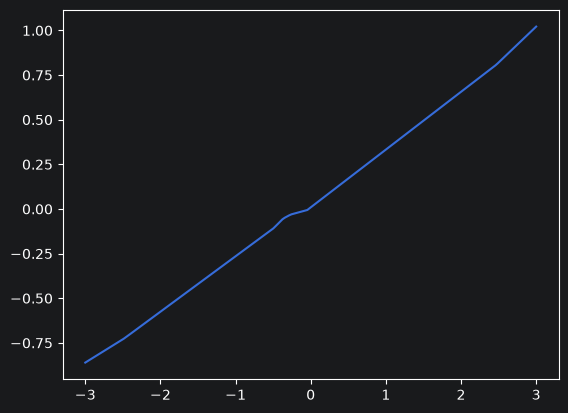

In [19]:
import matplotlib.pyplot as plt

x = torch.linspace(-3, 3, 200).unsqueeze(1)

torch.manual_seed(0)
net = nn.Sequential(nn.Linear(1, 8), nn.ReLU(), nn.Linear(8, 1))

plt.plot(x, net(x).detach())
plt.show()

In [30]:
x = torch.randn(5)
print(x.shape)
a = x.unsqueeze(0)
print(a.shape)
b = a.squeeze(0).unsqueeze(1)
print(b.shape)

torch.Size([5])
torch.Size([1, 5])
torch.Size([5, 1])
